In [93]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from IPython.display import display

In [94]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

try:
    df = pd.read_csv("../air_fryers_clean_brand_year.csv")
except FileNotFoundError:
    df = pd.read_csv("air_fryers_clean_brand_year.csv")

df["brand"] = df["brand"].replace({
    "gowise usa": "gowise_usa"
})

print(df.shape)
print("Brands:", sorted(df["brand"].unique()))
print("Years:", sorted(df["year"].unique()))
print("\nBrand share sums by year:")
print(df.groupby("year")["brand_share"].sum())

df.head()

(50, 15)
Brands: ['chefman', 'cosori', 'cuisinart', 'dash', 'gowise_usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Brand share sums by year:
year
2019   1.0000
2020   1.0000
2021   1.0000
2022   1.0000
2023   1.0000
Name: brand_share, dtype: float64


,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.9637,4.4341,1.0000,0.0000,0.7810,0.2435,0.1841,15076,0.0760,-2.5768
1,air_fryers,2019,cosori,11,2,159.9900,4.5818,1.0000,0.0000,0.0909,0.0909,0.0000,15076,0.0007,-7.2230
2,air_fryers,2019,cuisinart,1616,22,229.4653,4.4813,0.9938,0.0000,0.8899,0.0000,0.0000,15076,0.1072,-2.2332
3,air_fryers,2019,dash,3011,19,55.1763,4.3908,1.0000,0.0000,0.9734,0.0000,0.0000,15076,0.1997,-1.6108
4,air_fryers,2019,gowise_usa,4405,45,83.5756,4.5523,0.9998,0.0000,0.1294,0.1285,0.0000,15076,0.2922,-1.2304


In [95]:
feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share",
]

y = df["log_brand_share"]

brand_dummies = pd.get_dummies(
    df["brand"],
    prefix="brand",
    drop_first=True,
    dtype=int
)

year_dummies = pd.get_dummies(
    df["year"].astype(str),
    prefix="year",
    drop_first=True,
    dtype=int
)

X = pd.concat(
    [
        df[["avg_price", "avg_rating"] + feature_cols],
        brand_dummies,
        year_dummies
    ],
    axis=1
)

model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share)

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})

price_coef = coef_table.loc[
    coef_table["feature"] == "avg_price",
    "coefficient"
].iloc[0]

print("R-squared:", round(r2, 4))
print("Estimated price coefficient:", round(price_coef, 6))

display(coef_table)

R-squared: 0.7635
Estimated price coefficient: -0.037668


,feature,coefficient
0,avg_price,-0.0377
1,avg_rating,0.2875
2,compact_share,9.8153
3,dual_basket_share,-9.5097
4,oven_style_share,1.9418
5,rotisserie_share,-5.6741
6,window_share,12.8803
7,brand_cosori,2.5519
8,brand_cuisinart,6.4224
9,brand_dash,0.1767


In [96]:
results = df.copy()

results["predicted_log_share"] = predicted_log_share

results["demand_slope"] = (
    price_coef * results["brand_share"] * (1 - results["brand_share"])
)

results["unit_cost"] = (
    results["avg_price"] + results["brand_share"] / results["demand_slope"]
)

results["markup"] = results["avg_price"] - results["unit_cost"]

results["average_profit"] = results["brand_share"] * results["markup"]

# This checks whether the first-order condition is being satisfied.
# Values close to zero mean the calculation is working correctly.
results["profit_derivative"] = (
    results["demand_slope"] * results["markup"] + results["brand_share"]
)

print("Price coefficient:", price_coef)
print("Any positive demand slopes?", (results["demand_slope"] > 0).any())
print("Any negative unit costs?", (results["unit_cost"] < 0).any())
print("Largest absolute profit derivative:", results["profit_derivative"].abs().max())

display(results[
    [
        "year",
        "brand",
        "avg_price",
        "brand_share",
        "demand_slope",
        "unit_cost",
        "markup",
        "average_profit",
        "profit_derivative"
    ]
].head(10))

Price coefficient: -0.03766765298429363
Any positive demand slopes? False
Any negative unit costs? False
Largest absolute profit derivative: 5.551115123125783e-17


,year,brand,avg_price,brand_share,demand_slope,unit_cost,markup,average_profit,profit_derivative
0,2019,chefman,72.9637,0.0760,-0.0026,44.2317,28.7320,2.1841,0.0000
1,2019,cosori,159.9900,0.0007,-0.0000,133.4226,26.5674,0.0194,0.0000
2,2019,cuisinart,229.4653,0.1072,-0.0036,199.7300,29.7353,3.1873,0.0000
3,2019,dash,55.1763,0.1997,-0.0060,22.0029,33.1734,6.6254,0.0000
4,2019,gowise_usa,83.5756,0.2922,-0.0078,46.0685,37.5070,10.9590,0.0000
5,2019,instant_pot,78.0199,0.0158,-0.0006,51.0461,26.9738,0.4258,0.0000
6,2019,ninja,112.1584,0.1926,-0.0059,79.2766,32.8818,6.3338,-0.0000
7,2019,nuwave,151.0999,0.0321,-0.0012,123.6714,27.4285,0.8806,0.0000
8,2019,oster,191.9437,0.0336,-0.0012,164.4737,27.4700,0.9220,-0.0000
9,2019,ultrean,80.6247,0.0501,-0.0018,52.6771,27.9476,1.3996,0.0000


In [97]:
brand_summary = (
    results.groupby("brand")
    .agg(
        avg_price=("avg_price", "mean"),
        avg_rating=("avg_rating", "mean"),
        avg_share=("brand_share", "mean"),
        avg_unit_cost=("unit_cost", "mean"),
        avg_markup=("markup", "mean"),
        avg_profit=("average_profit", "mean"),
        total_purchases=("purchase_count", "sum"),
    )
    .sort_values("avg_profit", ascending=False)
)

display(brand_summary.round(4))

,avg_price,avg_rating,avg_share,avg_unit_cost,avg_markup,avg_profit,total_purchases
brand,,,,,,,
ninja,145.3425,4.7421,0.1916,112.4885,32.8541,6.3061,20074
instant_pot,104.4614,4.5593,0.1749,71.9031,32.5582,6.0103,19426
gowise_usa,87.4548,4.5770,0.1380,56.3010,31.1537,4.6058,14962
dash,57.4789,4.4764,0.0979,27.9366,29.5423,2.9944,10295
chefman,90.9384,4.4280,0.0951,61.5695,29.3689,2.8210,9437
ultrean,78.1146,4.6726,0.0924,48.7858,29.3288,2.7809,11914
cuisinart,223.9471,4.4389,0.0858,194.8961,29.0510,2.5030,9676
cosori,114.2679,4.6563,0.0490,86.2833,27.9846,1.4367,4147
nuwave,137.0244,4.3898,0.0506,109.0535,27.9708,1.4229,5741


In [98]:
avg_market_share = (
    results.groupby("brand")["brand_share"]
    .mean()
    .sort_values(ascending=False)
    .to_frame("avg_market_share")
)

avg_market_share["avg_market_share_percent"] = avg_market_share["avg_market_share"] * 100

display(avg_market_share.round(4))

,avg_market_share,avg_market_share_percent
brand,,
ninja,0.1916,19.1567
instant_pot,0.1749,17.4921
gowise_usa,0.1380,13.8005
dash,0.0979,9.7862
chefman,0.0951,9.5079
ultrean,0.0924,9.2369
cuisinart,0.0858,8.5787
nuwave,0.0506,5.0559
cosori,0.0490,4.8974


In [99]:
cost_markup_by_year = results[
    [
        "year",
        "brand",
        "avg_price",
        "brand_share",
        "unit_cost",
        "markup",
        "average_profit"
    ]
].sort_values(["brand", "year"])

display(cost_markup_by_year.round(4))

,year,brand,avg_price,brand_share,unit_cost,markup,average_profit
0,2019,chefman,72.9637,0.0760,44.2317,28.7320,2.1841
10,2020,chefman,97.4262,0.0581,69.2396,28.1866,1.6387
20,2021,chefman,92.0844,0.0843,63.0930,28.9913,2.4434
30,2022,chefman,98.4385,0.1167,68.3820,30.0564,3.5085
40,2023,chefman,93.7793,0.1402,62.9010,30.8783,4.3303
1,2019,cosori,159.9900,0.0007,133.4226,26.5674,0.0194
11,2020,cosori,115.6494,0.0086,88.8716,26.7778,0.2298
21,2021,cosori,97.4220,0.0351,69.9073,27.5148,0.9668
31,2022,cosori,97.8664,0.0730,69.2265,28.6398,2.0919
41,2023,cosori,100.4119,0.1274,69.9885,30.4233,3.8754


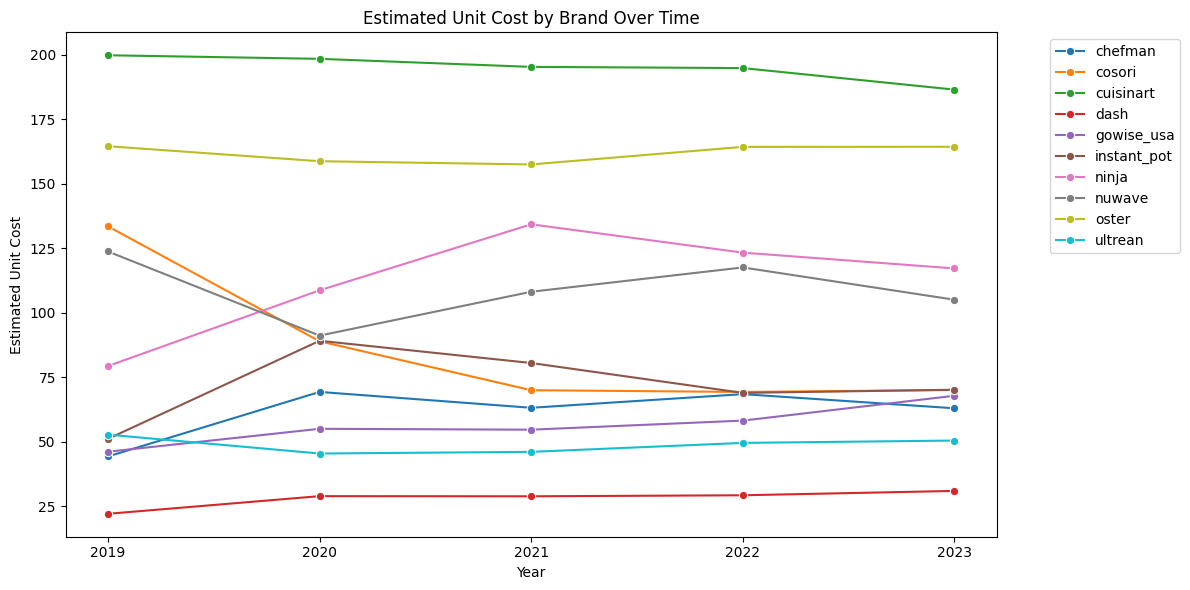

In [100]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=results,
    x="year",
    y="unit_cost",
    hue="brand",
    marker="o"
)

plt.title("Estimated Unit Cost by Brand Over Time")
plt.xlabel("Year")
plt.ylabel("Estimated Unit Cost")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.xticks(sorted(results["year"].unique()))
plt.show()

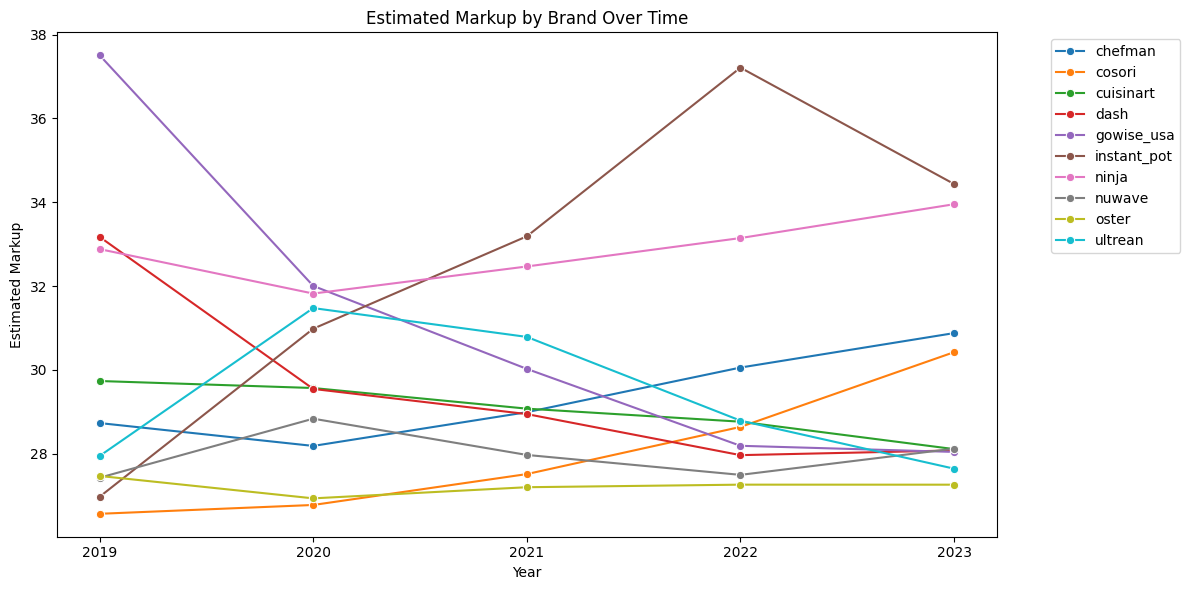

In [101]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=results,
    x="year",
    y="markup",
    hue="brand",
    marker="o"
)

plt.title("Estimated Markup by Brand Over Time")
plt.xlabel("Year")
plt.ylabel("Estimated Markup")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.xticks(sorted(results["year"].unique()))
plt.show()

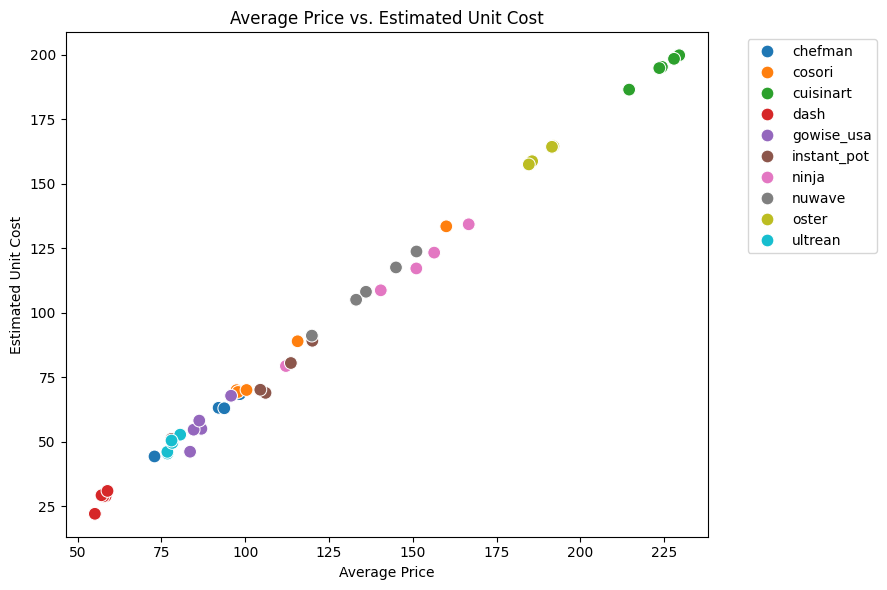

Correlation between average price and unit cost: 0.9988


In [102]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=results,
    x="avg_price",
    y="unit_cost",
    hue="brand",
    s=85
)

plt.title("Average Price vs. Estimated Unit Cost")
plt.xlabel("Average Price")
plt.ylabel("Estimated Unit Cost")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(
    "Correlation between average price and unit cost:",
    round(results["avg_price"].corr(results["unit_cost"]), 4)
)

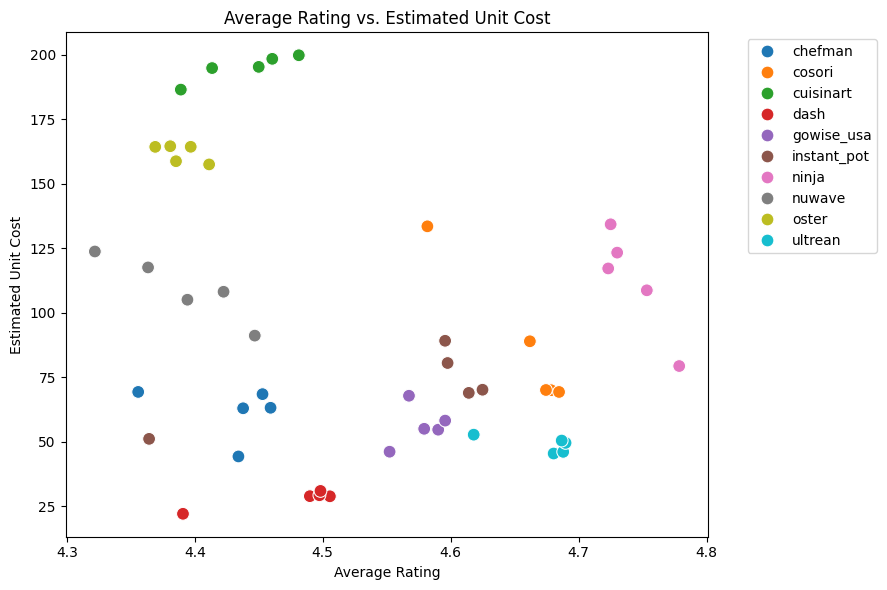

Correlation between average rating and unit cost: -0.3139
Correlation between average price and average rating: -0.2939


In [103]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=results,
    x="avg_rating",
    y="unit_cost",
    hue="brand",
    s=85
)

plt.title("Average Rating vs. Estimated Unit Cost")
plt.xlabel("Average Rating")
plt.ylabel("Estimated Unit Cost")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(
    "Correlation between average rating and unit cost:",
    round(results["avg_rating"].corr(results["unit_cost"]), 4)
)

print(
    "Correlation between average price and average rating:",
    round(results["avg_price"].corr(results["avg_rating"]), 4)
)

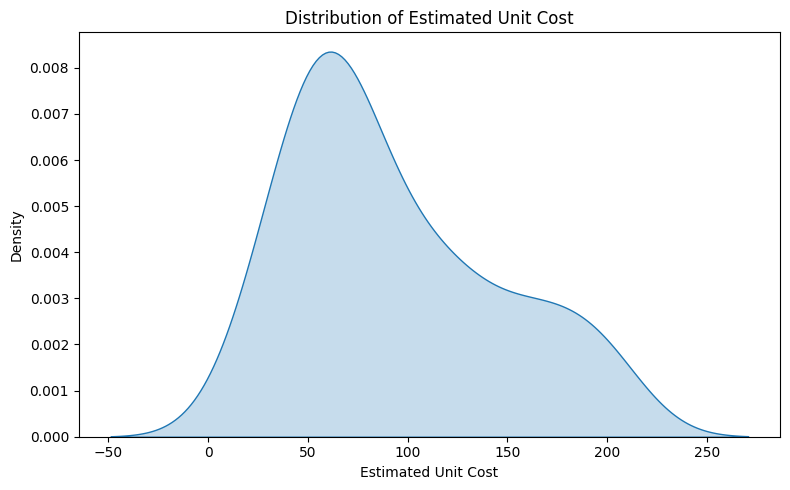

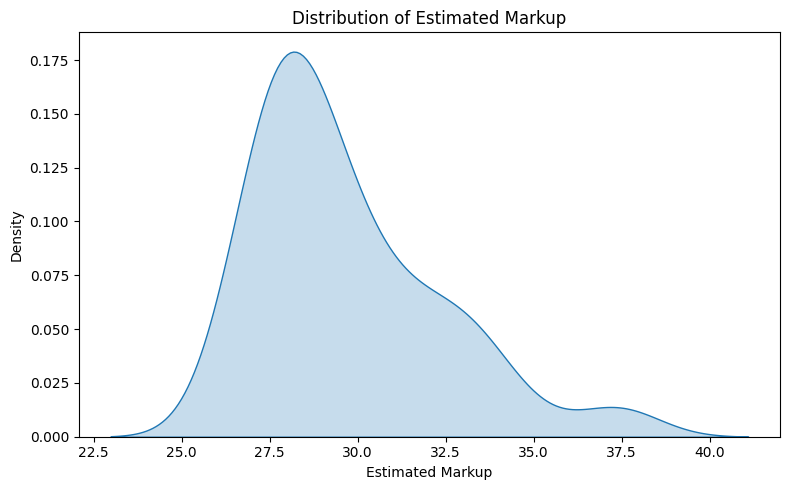

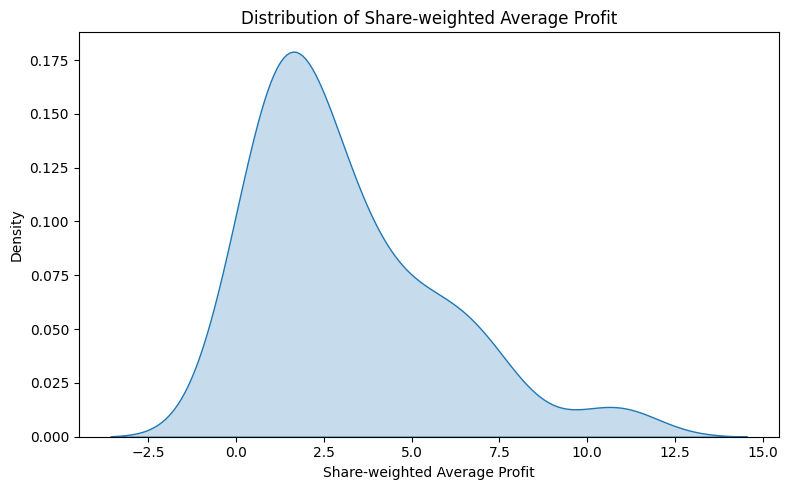

In [104]:
for col, label in [
    ("unit_cost", "Estimated Unit Cost"),
    ("markup", "Estimated Markup"),
    ("average_profit", "Share-weighted Average Profit"),
]:
    plt.figure(figsize=(8, 5))
    
    sns.kdeplot(
        data=results,
        x=col,
        fill=True,
        warn_singular=False
    )
    
    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

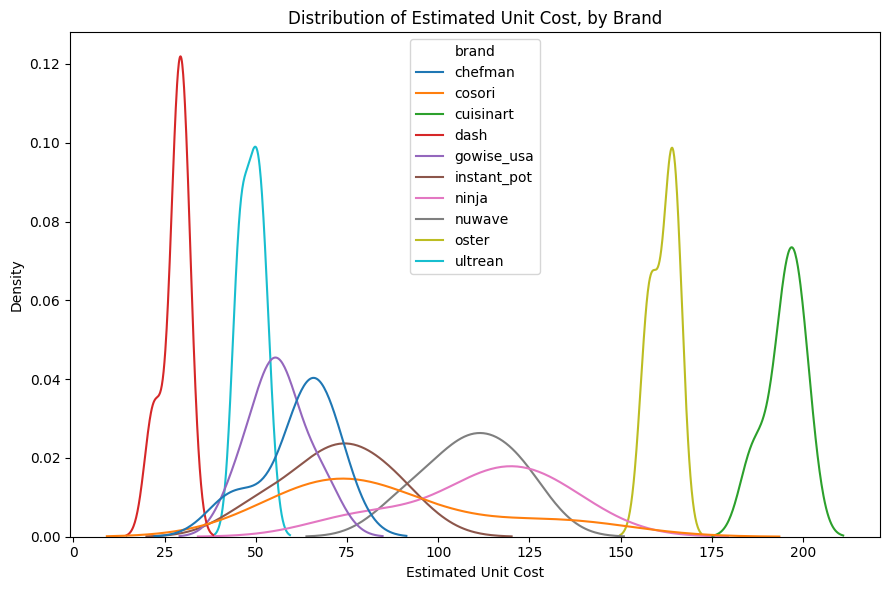

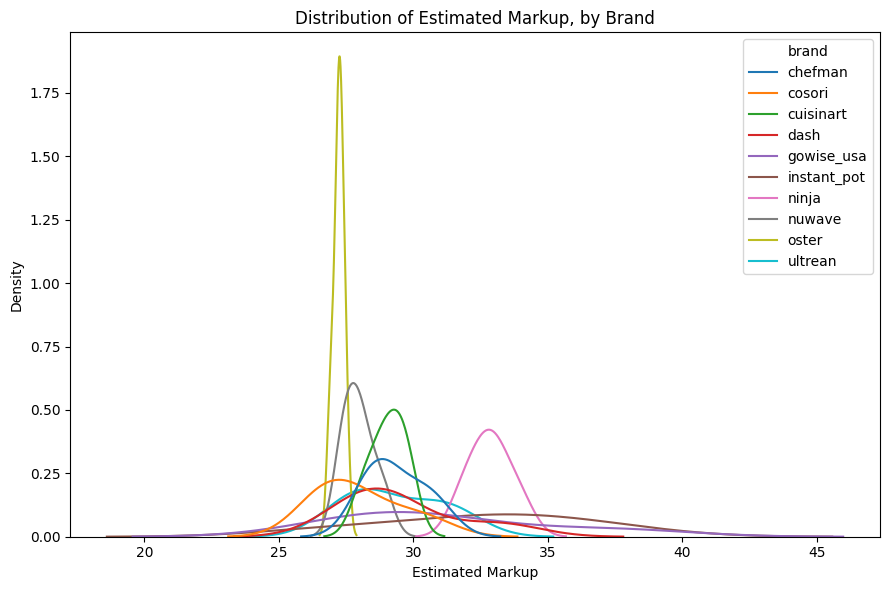

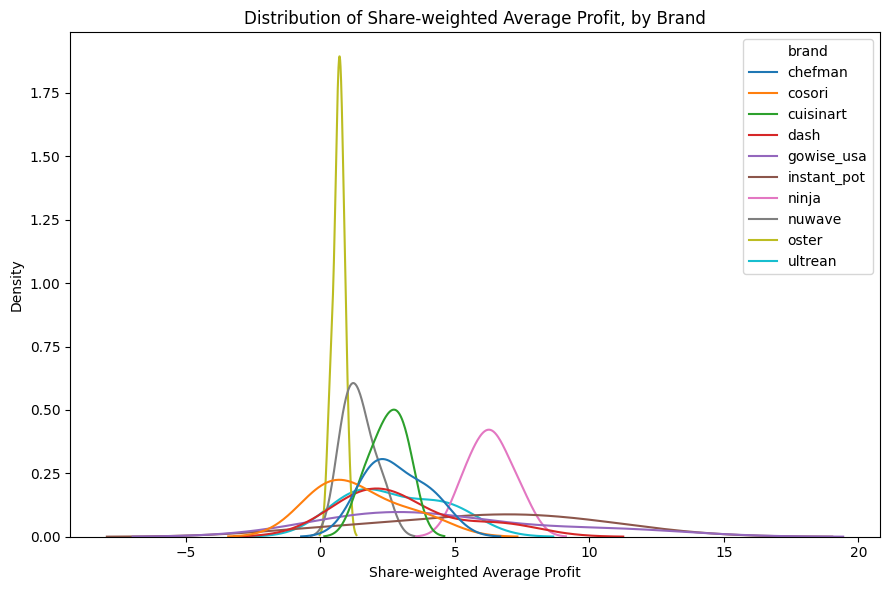

In [105]:
for col, label in [
    ("unit_cost", "Estimated Unit Cost"),
    ("markup", "Estimated Markup"),
    ("average_profit", "Share-weighted Average Profit"),
]:
    plt.figure(figsize=(9, 6))
    
    sns.kdeplot(
        data=results,
        x=col,
        hue="brand",
        common_norm=False,
        warn_singular=False
    )
    
    plt.title(f"Distribution of {label}, by Brand")
    plt.xlabel(label)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

,avg_price,avg_rating,avg_share,avg_markup,avg_profit
brand,,,,,
ninja,145.3425,4.7421,0.1916,32.8541,6.3061
instant_pot,104.4614,4.5593,0.1749,32.5582,6.0103
gowise_usa,87.4548,4.5770,0.1380,31.1537,4.6058
dash,57.4789,4.4764,0.0979,29.5423,2.9944
chefman,90.9384,4.4280,0.0951,29.3689,2.8210
ultrean,78.1146,4.6726,0.0924,29.3288,2.7809
cuisinart,223.9471,4.4389,0.0858,29.0510,2.5030
cosori,114.2679,4.6563,0.0490,27.9846,1.4367
nuwave,137.0244,4.3898,0.0506,27.9708,1.4229


,avg_market_share,avg_markup,avg_share_weighted_profit
brand,,,
ninja,0.1916,32.8541,6.3061
instant_pot,0.1749,32.5582,6.0103
gowise_usa,0.1380,31.1537,4.6058
dash,0.0979,29.5423,2.9944
chefman,0.0951,29.3689,2.8210
ultrean,0.0924,29.3288,2.7809
cuisinart,0.0858,29.0510,2.5030
cosori,0.0490,27.9846,1.4367
nuwave,0.0506,27.9708,1.4229


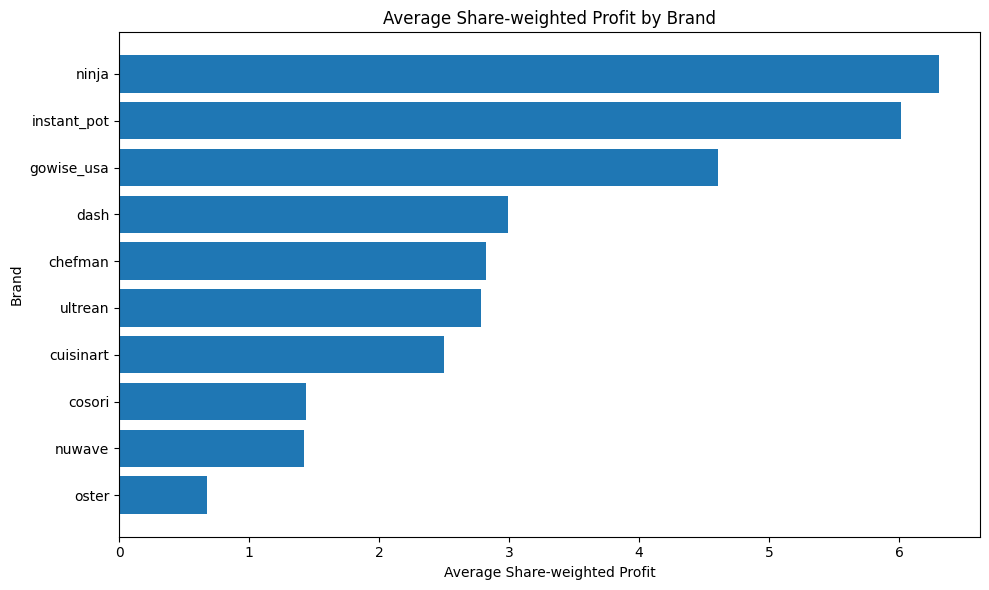

In [108]:
profit_ranking = brand_summary[
    ["avg_price", "avg_rating", "avg_share", "avg_markup", "avg_profit"]
].sort_values("avg_profit", ascending=False)

display(profit_ranking.round(4))

plt.figure(figsize=(10, 6))

plt.barh(profit_ranking.index, profit_ranking["avg_profit"])
plt.gca().invert_yaxis()

profit_explanation_table = (
    results.groupby("brand")
    .agg(
        avg_market_share=("brand_share", "mean"),
        avg_markup=("markup", "mean"),
        avg_share_weighted_profit=("average_profit", "mean")
    )
    .sort_values("avg_share_weighted_profit", ascending=False)
)

display(profit_explanation_table.round(4))

plt.title("Average Share-weighted Profit by Brand")
plt.xlabel("Average Share-weighted Profit")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

In [107]:
results.to_csv("air_fryer_pricing_results.csv", index=False)
brand_summary.to_csv("air_fryer_brand_pricing_summary.csv")

print("Saved air_fryer_pricing_results.csv")
print("Saved air_fryer_brand_pricing_summary.csv")

Saved air_fryer_pricing_results.csv
Saved air_fryer_brand_pricing_summary.csv


## Part 3 Answers: Costs, Markups, and Profit

**1. What are the average unit costs and markups for each brand over the years?**

Cuisinart has the highest average unit cost ($194.90), followed by Oster ($161.81), Ninja ($112.49), and Nuwave ($109.05). On the lower end, Dash ($27.94), Ultrean ($48.79), and GoWise USA ($56.30) have some of the lowest average unit costs. Despite this wide spread in costs, most brands have average markups clustered in a much narrower range, roughly from the high $20s to low $30s. Ninja has the highest average markup at $32.85, while Oster has the lowest at $27.23.

For unit costs over time, the main pattern is that higher-priced brands also have higher estimated unit costs. Cuisinart stays the highest-cost brand across all years, though it declines slightly by 2023. Oster is also consistently high-cost and stays relatively stable after 2021. Ninja rises sharply from 2019 to 2021, then decreases slightly in 2022 and 2023, but it still remains one of the higher-cost brands. Nuwave and Cosori both drop from 2019 to 2020, with Cosori falling especially sharply and staying lower afterward. On the lower end, Dash stays the lowest-cost brand throughout the period, while Chefman, GoWise USA, and Ultrean remain in the lower-to-middle cost range.

For markups over time, the differences between brands are much smaller than the differences in unit costs. Most estimated markups stay roughly between the high 20s and high 30s. GoWise USA starts with the highest markup in 2019, but its markup declines steadily after that. Instant Pot increases strongly from 2019 to 2022, reaching one of the highest markups, before falling slightly in 2023. Ninja has consistently high and gradually rising markups, which suggests it has strong market power over time. Cosori starts lower but increases by 2023. Dash starts relatively high but drops after 2019 and then stays lower. Overall, unit costs show bigger differences across brands, while markups are more clustered and mostly reflect changes in market share rather than price alone.

**2. Are any inferred unit costs negative? If so, what might that mean?**

None of the inferred unit costs are negative, which is a good sign because negative unit costs would not make economic sense. If we did get negative unit costs, it could mean something was wrong with the demand model, such as the price coefficient having the wrong sign, the market shares not being calculated correctly, or the pricing formula not fitting the data well. Since all unit costs are positive, the cost estimates are more reasonable to interpret. Since our price coefficient is negative (-0.0377), the demand slopes are also negative, and the cost formula produces economically reasonable positive values throughout.

**3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Do more expensive products have higher consumer satisfaction?**

The brands with the highest estimated average unit costs are Cuisinart ($194.90), Oster ($161.81), Ninja ($112.49), and Nuwave ($109.05), which closely tracks the price ranking. Average unit cost is very closely related to average price, with a correlation of 0.9988. This makes sense because unit cost is calculated as price minus markup, so brands with higher prices usually end up with higher inferred costs. However, higher unit cost does not necessarily mean higher consumer satisfaction. The correlation between average rating and unit cost is -0.3139, and the correlation between average price and average rating is -0.2939. This suggests that more expensive products do not automatically have higher consumer satisfaction in this market.

**4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.**

The KDE plots show that estimated unit costs have the widest spread across brands, meaning brands differ a lot in their inferred costs. This matches the air fryer market because some brands are more budget-oriented, while others are more premium-priced. Markups are much more tightly clustered than unit costs, so brands differ less in how much they charge above estimated cost. Average profit is mostly concentrated at lower values but has a right tail because a few brands combine strong markups with high market share. Overall, the plots suggest that differences in profitability come from both pricing power and market share, not just price alone.


**5. Which brands have the highest share-weighted average profit?**

The brands with the highest share-weighted average profit are Ninja, Instant Pot, and GoWise USA. Ninja leads because it combines the largest market share (19.2%) with the highest markup ($32.85). Instant Pot follows with a strong share (17.5%) and competitive markup ($32.56). GoWise has a lower average price than brands like Ninja or Cuisinart, but it still ranks highly because it has a strong average market share. Cuisinart and Oster, despite commanding the highest prices and costs in the market, are held back by small shares (8.6% and 2.5% respectively), which limits their share-weighted profit to just 2.50 and 0.68. Overall, this shows that high price alone does not guarantee high profit in this model. The most profitable brands are the ones that combine a decent markup with strong market share.